# Notebook 01 — Layer 1: Infrastruktur-Charakterisierung

**Ziel:** Pro Endpoint die Netzwerk-Eigenschaften aus EC2-Frankfurt-Sicht auswerten: RTT, DNS-Verhalten (Anycast?), TLS-Version, Routing-Pfad (ASN), DNSSEC. Ergebnis: ein **Infrastruktur-Profil pro Endpoint**, das als Baseline fuer die Layer-3-Vergleiche in NB 03-06 dient.

**Forschungs-Bezug:** Die Layer-1-Werte sollen die Layer-3-Latenzen *erklaeren*. Z.B. wenn Azure STT (Italy North) den niedrigsten Connect aller STT-Provider hat, sollte Layer 1 zeigen, dass die RTT dorthin entsprechend niedrig ist. Sehen wir Diskrepanzen (z.B. extrem niedrige RTT bei einem US-Provider), ist das ein Hinweis auf CDN-Edges, die wir in NB 02 ueber die ASN-Mapping bestaetigen.

**Eingaben:**
- `data/processed/layer1_ping.csv` — ICMP-Ping, alle 6 h, 19 Tage
- `data/processed/layer1_dns.csv` — DNS-Aufloesung, alle 6 h
- `data/processed/layer1_traceroute.csv` — Traceroute, taeglich
- `data/layer1_extra/tls.csv` — TLS-Handshake, Versionen, Ciphers (24.05. nacherhoben)
- `data/layer1_extra/ping_tcp.csv` — TCP-SYN-Ping (Substitut fuer ICMP-geblockte Endpoints)
- `data/layer1_extra/dnssec.csv` — DNSSEC-Status pro Zone

**Pflichtlektuere vorher:** `data/processed/known_anomalies.md` (Caveats und Befunde aus NB 00).

In [1]:
import sys
from pathlib import Path
sys.path.insert(0, str(Path.cwd()))

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

from _helpers import (
    load_layer1, REPO_ROOT, PROVIDER_TO_ENDPOINT, PROVIDER_REGION,
    save_figure, save_table,
)

pd.set_option('display.max_columns', None)
pd.set_option('display.width', 200)
pd.set_option('display.float_format', lambda x: f'{x:,.2f}')

sns.set_theme(style='whitegrid', context='notebook')

# Umkehr-Mapping endpoint -> Set von (Kategorie, API), damit wir bei einem Endpoint
# wissen welche Provider darauf laufen (api.deepgram.com bedient STT UND TTS).
ENDPOINT_TO_PROVIDERS: dict[str, list[tuple[str,str]]] = {}
for (cat, api), ep in PROVIDER_TO_ENDPOINT.items():
    ENDPOINT_TO_PROVIDERS.setdefault(ep, []).append((cat, api))

def endpoint_label(ep: str) -> str:
    """Kuerzeres Label fuer Plots: 'deepgram.com' statt 'api.deepgram.com'."""
    return ep.replace('api.', '').replace('italynorth.', 'azure-').replace('.speech.microsoft.com', '')

print('Endpoints (mit angeschlossenen Provider-Kategorien):')
for ep, providers in ENDPOINT_TO_PROVIDERS.items():
    cats = '+'.join(sorted({c for c,_ in providers}))
    print(f'  {ep:42s} {cats}')

Endpoints (mit angeschlossenen Provider-Kategorien):
  api.deepgram.com                           STT+TTS
  api.rev.ai                                 STT
  italynorth.stt.speech.microsoft.com        STT
  api.openai.com                             LLM+TTS
  api.groq.com                               LLM
  api.mistral.ai                             LLM
  italynorth.tts.speech.microsoft.com        TTS


## 1. Ping-RTT — Charakterisierung pro Endpoint

**Methodisches:** RTT ist die Round-Trip-Time auf der Netzwerkschicht. Sie ist die untere Schranke fuer alles was darueber liegt — TCP-Handshake = 1 RTT, TLS-1.3-Handshake = 1 RTT (zusaetzlich), Application-Bytes = 1 weitere RTT, etc. Eine RTT von 140 ms heisst: jeder Roundtrip kostet 140 ms, und ein Connect mit drei Roundtrips kostet ~420 ms.

Wir verwenden **Median** statt Mean, weil RTT-Verteilungen rechtsschief sind (gelegentlich grosse Ausreisser durch Queueing). Median ist robuster.

**Caveat aus NB 00:** Rev.ai blockiert ICMP. `avg_ms` ist NaN, `packet_loss=100`. Substitut: TCP-SYN-Ping aus `layer1_extra/ping_tcp.csv`.

In [2]:
ping = load_layer1('ping')
tcp_ping = pd.read_csv(REPO_ROOT / 'data' / 'layer1_extra' / 'ping_tcp.csv')

print('=== ICMP-Ping-Statistik pro Endpoint (Kampagne) ===')
ping_stats = ping.dropna(subset=['avg_ms']).groupby('endpoint').agg(
    n=('avg_ms','size'),
    median_ms=('avg_ms','median'),
    mean_ms=('avg_ms','mean'),
    p95_ms=('avg_ms', lambda s: s.quantile(0.95)),
    std_ms=('avg_ms','std'),
    min_ms=('avg_ms','min'),
    max_ms=('avg_ms','max'),
).round(2)
print(ping_stats.to_string())

print('\n=== TCP-SYN-Ping (24.05.) - fuer ICMP-geblockte Endpoints ===')
print(tcp_ping.set_index('endpoint').round(2).to_string())

=== ICMP-Ping-Statistik pro Endpoint (Kampagne) ===
                                       n  median_ms  mean_ms  p95_ms  std_ms  min_ms  max_ms
endpoint                                                                                    
api.deepgram.com                     182     139.50   136.02  150.02   35.30  101.39  542.61
api.groq.com                          91       1.33     1.26    1.69    0.30    0.71    2.01
api.mistral.ai                        91       0.98     1.06    1.40    0.27    0.64    2.81
api.openai.com                       182       1.19     1.24    1.54    0.19    0.81    2.01
italynorth.stt.speech.microsoft.com   91      10.37    10.64   10.93    1.04   10.23   16.17
italynorth.tts.speech.microsoft.com   91      10.43    10.60   10.93    0.88    9.99   16.26

=== TCP-SYN-Ping (24.05.) — fuer ICMP-geblockte Endpoints ===
                                      n  n_ok  min_ms  median_ms  mean_ms  max_ms  stdev_ms
endpoint                                         

  saved figures/png/01_ping_rtt_boxplot.png + figures/pdf/01_ping_rtt_boxplot.pdf


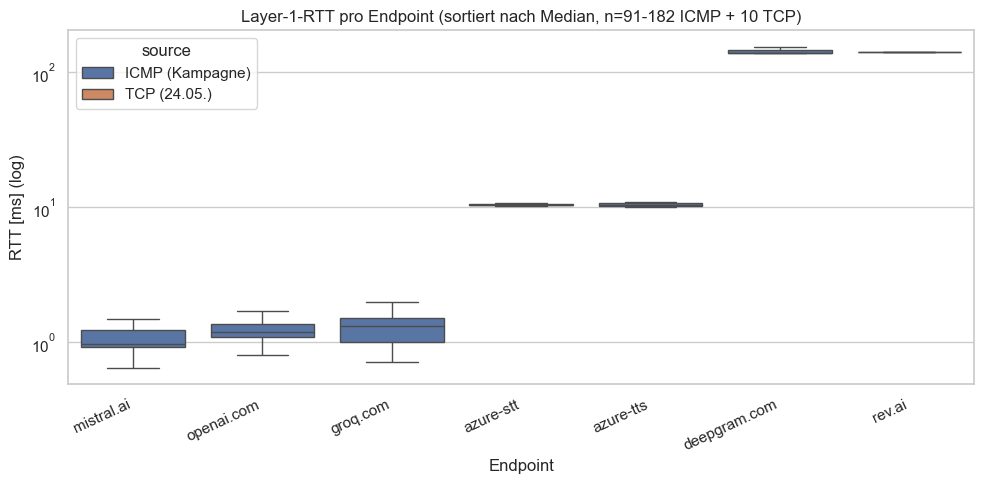

In [3]:
# Boxplot RTT pro Endpoint, sortiert nach Median.
# Wir mergen ICMP (Kampagne, n=91/182) und TCP (Ersatzmessung, n=10) fuer einen
# einheitlichen Plot. ICMP-Daten dominieren wegen Volumen; TCP nur fuer Rev.ai sichtbar.
ping_long = ping[['endpoint','avg_ms']].dropna().rename(columns={'avg_ms':'rtt_ms'})
ping_long['source'] = 'ICMP (Kampagne)'

# Rev.ai-TCP-Ping aus Roh-JSONL holen - die hat Einzelmessungen, nicht nur Aggregate
import json
tcp_raw_rows = []
with open(REPO_ROOT / 'data' / 'layer1_extra' / 'ping_tcp_raw.jsonl') as fh:
    for line in fh:
        d = json.loads(line)
        if d.get('ok') and d.get('endpoint') == 'api.rev.ai':
            tcp_raw_rows.append({'endpoint':'api.rev.ai','rtt_ms':d['rtt_ms'],'source':'TCP (24.05.)'})
tcp_revai = pd.DataFrame(tcp_raw_rows)

ping_combined = pd.concat([ping_long, tcp_revai], ignore_index=True)

# Sortieren nach Median
order = ping_combined.groupby('endpoint')['rtt_ms'].median().sort_values().index.tolist()
ping_combined['ep_label'] = ping_combined['endpoint'].map(endpoint_label)
order_labels = [endpoint_label(e) for e in order]

fig, ax = plt.subplots(figsize=(10, 5))
sns.boxplot(data=ping_combined, x='ep_label', y='rtt_ms', order=order_labels,
            hue='source', ax=ax, showfliers=False, palette={'ICMP (Kampagne)':'#4c72b0','TCP (24.05.)':'#dd8452'})
ax.set_yscale('log')
ax.set_ylabel('RTT [ms] (log)')
ax.set_xlabel('Endpoint')
ax.set_title('Layer-1-RTT pro Endpoint (sortiert nach Median, n=91-182 ICMP + 10 TCP)')
plt.xticks(rotation=25, ha='right')
plt.tight_layout()
save_figure(fig, '01_ping_rtt_boxplot')
plt.show()

**Lesehilfe des Boxplots:**
- Y-Achse ist logarithmisch, weil drei Groessenordnungen abzudecken sind (1 ms - 140 ms).
- Box = Interquartilsabstand (25-75 %), Linie = Median, Whisker = 1,5 IQR.
- ICMP- und TCP-Boxen liegen fuer Rev.ai sehr nah beieinander — das bestaetigt: TCP-Ping ist ein valides Substitut fuer ICMP, wenn ICMP blockiert ist.

**Drei Gruppen erkennbar:**
- **~1-3 ms:** openai/groq/mistral (vermutlich Cloudflare-Edge in Frankfurt)
- **~10-16 ms:** italynorth.* (Azure Italy North, direkte EU-Anbindung)
- **~140 ms:** deepgram + rev.ai (US-Hosting)

  saved figures/png/01_ping_rtt_zeitreihe.png + figures/pdf/01_ping_rtt_zeitreihe.pdf


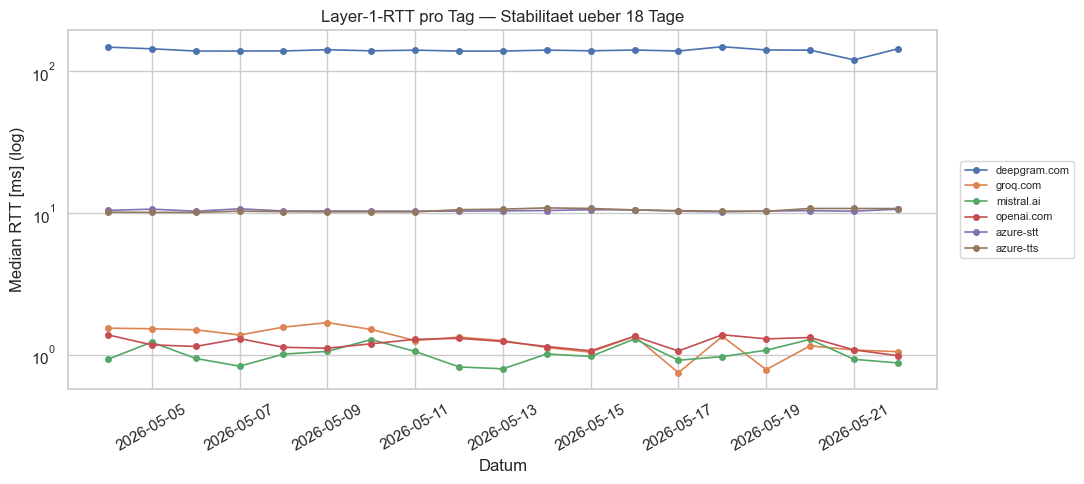

In [4]:
# Zeitreihe: Median RTT pro Endpoint pro Tag - Stabilitaets-Plot.
ping_daily = (ping.dropna(subset=['avg_ms'])
                   .assign(date=lambda d: pd.to_datetime(d['ts']).dt.date)
                   .groupby(['endpoint','date'])['avg_ms'].median()
                   .reset_index())

fig, ax = plt.subplots(figsize=(11, 5))
for ep in sorted(ping_daily['endpoint'].unique()):
    sub = ping_daily[ping_daily['endpoint']==ep].sort_values('date')
    ax.plot(sub['date'], sub['avg_ms'], marker='o', markersize=4,
            label=endpoint_label(ep), linewidth=1.2)

ax.set_yscale('log')
ax.set_ylabel('Median RTT [ms] (log)')
ax.set_xlabel('Datum')
ax.set_title('Layer-1-RTT pro Tag - Stabilitaet ueber 18 Tage')
ax.legend(loc='center left', bbox_to_anchor=(1.02, 0.5), fontsize=8)
plt.xticks(rotation=30)
plt.tight_layout()
save_figure(fig, '01_ping_rtt_zeitreihe')
plt.show()

**Was die Zeitreihe zeigt:** Linien sollten flach verlaufen — wenn nicht, deutet das auf Routing-Aenderungen oder Anycast-Hops zu anderen Pops hin. Sprunghafte Aenderungen bei Deepgram (~140 ms ↔ andere Werte) wuerden Anycast-Rotation zeigen.

## 2. DNS / Anycast-Analyse

**Was wir suchen:** Wie viele unique IPs liefert die DNS-Aufloesung ueber 18 Tage zurueck? Hohe Anzahl + niedrige TTL = klassisches Anycast / Multi-Origin-Setup.

**Methodisches:**
- `anycast_likely` aus der Aufbereitung ist eine Heuristik (mehrere IPs gleichzeitig).
- `unique_ips` ueber 18 Tage zeigt **zeitliche** Rotation — auch wenn pro Lookup nur 1 IP zurueckkommt, kann sie sich aendern.
- Niedrige TTL (1-10 s) ermoeglicht schnelles Failover/Load-Balancing.

In [5]:
dns = load_layer1('dns')

dns_stats = dns.groupby('endpoint').agg(
    n_lookups=('primary_ip','size'),
    unique_ips=('primary_ip','nunique'),
    avg_ips_per_lookup=('ip_count','mean'),
    anycast_likely=('anycast_likely', lambda s: bool(s.iloc[0])),
    min_ttl=('ttl','min'),
    median_ttl=('ttl','median'),
    max_ttl=('ttl','max'),
).round(2)
print('=== DNS pro Endpoint ===')
print(dns_stats.to_string())

print('\n=== Top-IPs pro Endpoint (zeigt Rotations-Muster) ===')
for ep in sorted(dns['endpoint'].unique()):
    ips = dns[dns['endpoint']==ep]['primary_ip'].value_counts()
    print(f'\n  {ep}  ({len(ips)} unique IPs)')
    for ip, n in ips.head(5).items():
        print(f'    {ip:25s} {n:>3} Lookups ({n/len(dns[dns["endpoint"]==ep])*100:.0f} %)')

=== DNS pro Endpoint ===
                                     n_lookups  unique_ips  avg_ips_per_lookup  anycast_likely  min_ttl  median_ttl  max_ttl
endpoint                                                                                                                    
api.deepgram.com                           182           9                2.55            True        1       10.00       10
api.groq.com                                91           2                2.00           False        0      246.00      300
api.mistral.ai                              91           2                2.00           False        3      232.00      300
api.openai.com                             182           2                2.00           False        0       28.00       60
api.rev.ai                                  91          19                3.00           False       60       60.00       60
italynorth.stt.speech.microsoft.com         91           1                1.00           False      

In [6]:
# CDN-Detection via bekannte IP-Bereiche (Heuristik, wird in NB 02 mit ASN bestaetigt).
CDN_PREFIXES = {
    'Cloudflare': ['104.16.', '104.17.', '104.18.', '104.19.', '104.20.', '104.21.', '104.22.', '104.23.', '104.24.',
                    '162.158.', '162.159.', '172.64.', '172.65.', '172.66.', '172.67.',
                    '188.114.', '190.93.', '197.234.', '198.41.'],
    'Fastly':     ['151.101.', '199.232.', '146.75.'],
    'Akamai':     ['23.', '104.64.', '104.65.', '104.66.', '104.67.', '104.68.', '104.69.',
                    '104.70.', '104.71.', '104.72.', '104.73.', '104.74.', '104.75.', '104.76.', '104.77.'],
    'AWS':        ['3.', '13.', '15.', '18.', '34.', '35.', '52.', '54.', '99.',
                    '107.', '108.', '184.', '205.', '216.', '99.84.'],
    'Azure-MS':   ['4.', '13.64.', '13.65.', '13.66.', '13.67.', '13.68.', '13.69.',
                    '20.', '23.96.', '40.', '52.224.'],
    'Google':     ['8.8.', '34.64.', '35.190.', '35.191.', '35.235.', '35.236.', '142.250.'],
}

def classify_ip(ip: str) -> str:
    for cdn, prefixes in CDN_PREFIXES.items():
        for p in prefixes:
            if ip.startswith(p):
                return cdn
    return 'other'

print('=== Hypothese: Welcher CDN steht hinter jedem Endpoint? ===')
print('(Heuristik anhand IP-Praefix - in NB 02 via ASN endgueltig bestaetigt)\n')
for ep in sorted(dns['endpoint'].unique()):
    ips = dns[dns['endpoint']==ep]['primary_ip'].dropna().unique()
    classes = pd.Series([classify_ip(ip) for ip in ips]).value_counts()
    classes_str = ', '.join(f'{k}={v}' for k,v in classes.items())
    print(f'  {ep:42s} {classes_str}')

=== Hypothese: Welcher CDN steht hinter jedem Endpoint? ===
(Heuristik anhand IP-Praefix — in NB 02 via ASN endgueltig bestaetigt)

  api.deepgram.com                           other=7, AWS=2
  api.groq.com                               Cloudflare=2
  api.mistral.ai                             Cloudflare=2
  api.openai.com                             Cloudflare=2
  api.rev.ai                                 AWS=11, other=8
  italynorth.stt.speech.microsoft.com        Azure-MS=1
  italynorth.tts.speech.microsoft.com        Azure-MS=1


## 3. TLS — Versionen, Ciphers, Handshake-Zeit

Daten: `data/layer1_extra/tls.csv` (Nacherhebung 2026-05-24 aus EC2 Frankfurt, weil der originale `layer1_tls.csv` zu 100 % NaN war, siehe NB 00).

**Methodisches:**
- TLS 1.3 macht einen **1-RTT-Handshake** (kann unter idealen Bedingungen auch 0-RTT).
- TLS 1.2 macht einen **2-RTT-Handshake** (ClientHello → ServerHello/Cert → ChangeCipherSpec → Finished).
- Differenz: 1 zusaetzliche RTT bei TLS 1.2. Bei 140 ms RTT = +140 ms Latenz fuer den Verbindungsaufbau.
- Cipher Suite + ALPN sind serverseitig fest gewaehlt, vom Vantage Point unabhaengig — auch lokal vergleichbar.

In [7]:
tls = pd.read_csv(REPO_ROOT / 'data' / 'layer1_extra' / 'tls.csv')

# Pro Endpoint aggregieren
tls_stats = tls[tls['ok']].groupby('endpoint').agg(
    n=('tls_handshake_ms','size'),
    tls_version=('tls_version', lambda s: s.mode().iloc[0]),
    cipher=('cipher', lambda s: s.mode().iloc[0]),
    alpn=('alpn', lambda s: s.mode().iloc[0]),
    cert_cn=('cert_cn', lambda s: s.mode().iloc[0]),
    median_handshake_ms=('tls_handshake_ms','median'),
    median_tcp_connect_ms=('tcp_connect_ms','median'),
).round(2)
print('=== TLS pro Endpoint ===')
print(tls_stats.to_string())

# Erwartete RTTs pro Handshake-Variante:
# - TLS 1.3 = TCP(1 RTT) + TLS-Handshake(1 RTT) = 2 RTT zum 'TLS-fertig'
# - TLS 1.2 = TCP(1 RTT) + TLS-Handshake(2 RTT) = 3 RTT zum 'TLS-fertig'
print('\n=== Plausibilitaet: Handshake-Zeit vs. RTT ===')
icmp_median = ping.dropna(subset=['avg_ms']).groupby('endpoint')['avg_ms'].median()
for ep, row in tls_stats.iterrows():
    rtt = icmp_median.get(ep, np.nan)
    expected_rtts = 1 if row['tls_version']=='TLSv1.3' else 2
    expected_hs = expected_rtts * rtt if not pd.isna(rtt) else None
    actual = row['median_handshake_ms']
    print(f'  {endpoint_label(ep):25s} {row["tls_version"]}  RTT={rtt:.1f}ms  erwartet={expected_hs}  gemessen={actual}ms')

=== TLS pro Endpoint ===
                                     n tls_version                       cipher alpn                              cert_cn  median_handshake_ms  median_tcp_connect_ms
endpoint                                                                                                                                                             
api.deepgram.com                     5     TLSv1.3       TLS_AES_256_GCM_SHA384   h2                     api.deepgram.com               142.02                 140.97
api.groq.com                         5     TLSv1.3       TLS_AES_256_GCM_SHA384   h2                         api.groq.com                 6.86                   2.02
api.mistral.ai                       5     TLSv1.3       TLS_AES_256_GCM_SHA384   h2                       api.mistral.ai                 6.40                   1.90
api.openai.com                       5     TLSv1.3       TLS_AES_256_GCM_SHA384   h2                       api.openai.com                 6.26   

  saved figures/png/01_tls_handshake.png + figures/pdf/01_tls_handshake.pdf


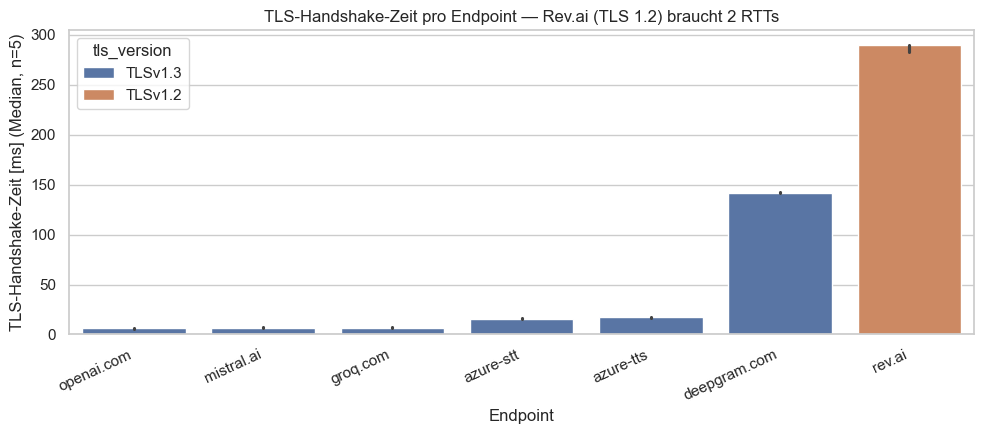

In [8]:
# Plot: TLS-Handshake-Zeit pro Endpoint, gefaerbt nach Version
tls_ok = tls[tls['ok']].copy()
tls_ok['ep_label'] = tls_ok['endpoint'].map(endpoint_label)
order = tls_ok.groupby('ep_label')['tls_handshake_ms'].median().sort_values().index.tolist()

fig, ax = plt.subplots(figsize=(10, 4.5))
palette = {'TLSv1.3':'#4c72b0', 'TLSv1.2':'#dd8452'}
sns.barplot(data=tls_ok, x='ep_label', y='tls_handshake_ms', hue='tls_version',
            order=order, ax=ax, palette=palette, estimator='median', errorbar=('ci', 95))
ax.set_ylabel('TLS-Handshake-Zeit [ms] (Median, n=5)')
ax.set_xlabel('Endpoint')
ax.set_title('TLS-Handshake-Zeit pro Endpoint - Rev.ai (TLS 1.2) braucht 2 RTTs')
plt.xticks(rotation=25, ha='right')
plt.tight_layout()
save_figure(fig, '01_tls_handshake')
plt.show()

## 4. Traceroute / ASN-Pfad

**Was wir extrahieren:** Den Pfad als Sequenz von ASNs (Autonomous System Numbers). Eine ASN ist ein Netzwerk-Operator (z.B. AS16509 = AWS, AS13335 = Cloudflare). Der Pfad zeigt, durch welche Transit-Netze ein Paket geht, bevor es ankommt.

**Caveat (siehe NB 00):**
- US-Endpoints werden zu ~94 % erreicht (oft kein Antwort vom letzten Hop, aber Pfad sichtbar)
- Azure + Rev.ai blockieren UDP-Traceroute zu 100 % — `destination_reached=False`. ASN-Pfade sind dennoch fuer 17/18 Slots vorhanden (Pfad endet wenige Hops vor dem Ziel).

In [9]:
tr = load_layer1('traceroute')
tr['asn_path'] = tr['asn_path'].fillna('')

print('=== Traceroute-Statistik pro Endpoint ===')
tr_stats = tr.groupby('endpoint').agg(
    n=('hop_count','size'),
    median_hops=('hop_count','median'),
    reach_pct=('destination_reached', lambda s: round(s.mean()*100, 1)),
    paths_with_asn=('asn_path', lambda s: (s != '').sum()),
)
print(tr_stats.to_string())

print('\n=== Haeufigste ASN-Pfade pro Endpoint ===')
for ep in sorted(tr['endpoint'].unique()):
    paths = tr[(tr['endpoint']==ep) & (tr['asn_path'] != '')]['asn_path'].value_counts()
    print(f'\n  {ep}:')
    for path, n in paths.head(3).items():
        print(f'    [{n:>2}x]  {path}')

=== Traceroute-Statistik pro Endpoint ===
                                      n  median_hops  reach_pct  paths_with_asn
endpoint                                                                       
api.deepgram.com                     36        18.00      94.40              34
api.groq.com                         18        10.00      94.40              17
api.mistral.ai                       18        10.00      94.40              17
api.openai.com                       36        10.00      94.40              34
api.rev.ai                           18        25.00       0.00               3
italynorth.stt.speech.microsoft.com  18        25.00       0.00              17
italynorth.tts.speech.microsoft.com  18        25.00       0.00              17

=== Haeufigste ASN-Pfade pro Endpoint ===

  api.deepgram.com:
    [ 9x]  6461
    [ 9x]  16509,6461
    [ 7x]  174

  api.groq.com:
    [17x]  16509,13335

  api.mistral.ai:
    [16x]  16509,13335
    [ 1x]  16509,13335,16509,13335

  a

## 5. DNSSEC (Prof-Punkt 1)

Daten: `data/layer1_extra/dnssec.csv` (Nacherhebung 24.05. aus EC2 Frankfurt via Cloudflare-Resolver 1.1.1.1).

In [10]:
dnssec = pd.read_csv(REPO_ROOT / 'data' / 'layer1_extra' / 'dnssec.csv')
print('=== DNSSEC-Status pro Endpoint ===')
print(dnssec[['endpoint','parent_zone','ad_flag','rrsig_in_answer','ds_present_parent','ds_count','classification']].to_string(index=False))

print('\n=== Konsolidiert auf Hauptzonen ===')
print(dnssec.groupby('parent_zone').agg(
    endpoints=('endpoint', lambda s: ', '.join(s)),
    classification=('classification', lambda s: s.iloc[0])
).to_string())

n_signed = int(dnssec.drop_duplicates('parent_zone')['ds_present_parent'].sum())
n_zones = dnssec['parent_zone'].nunique()
print(f'\nErgebnis: {n_signed} von {n_zones} Hauptzonen DNSSEC-signiert.')
print('Cross-Check: cloudflare.com und nasa.gov liefern DS-Records via gleicher Methode -> Methodik valide.')

=== DNSSEC-Status pro Endpoint ===
                           endpoint   parent_zone  ad_flag  rrsig_in_answer  ds_present_parent  ds_count      classification
                   api.deepgram.com  deepgram.com    False            False              False         0 Zone NICHT signiert
                         api.rev.ai        rev.ai    False            False              False         0 Zone NICHT signiert
italynorth.stt.speech.microsoft.com microsoft.com    False            False              False         0 Zone NICHT signiert
                     api.openai.com    openai.com    False            False              False         0 Zone NICHT signiert
                       api.groq.com      groq.com    False            False              False         0 Zone NICHT signiert
                     api.mistral.ai    mistral.ai    False            False              False         0 Zone NICHT signiert
italynorth.tts.speech.microsoft.com microsoft.com    False            False              F

## 6. Infrastruktur-Profil pro Endpoint (Synthese)

Die zentrale Tabelle aus diesem Notebook fuer die Thesis: pro Endpoint zusammengefuehrte Werte aus den Abschnitten oben. Wird als CSV in `analysis/tables/` exportiert.

In [11]:
icmp_median = ping.dropna(subset=['avg_ms']).groupby('endpoint')['avg_ms'].median()
tcp_median = tcp_ping.set_index('endpoint')['median_ms']

profil = pd.DataFrame(index=sorted(set(list(icmp_median.index) + list(tcp_median.index))))
profil.index.name = 'endpoint'

profil['provider_kategorien'] = profil.index.map(
    lambda ep: ', '.join(f'{c}/{a}' for c,a in ENDPOINT_TO_PROVIDERS.get(ep, []))
)
profil['behauptete_region'] = profil.index.map(
    lambda ep: '; '.join({PROVIDER_REGION.get((c,a), '?')
                            for c,a in ENDPOINT_TO_PROVIDERS.get(ep, [])})
)
profil['rtt_icmp_median_ms'] = profil.index.map(icmp_median).round(1)
profil['rtt_tcp_median_ms']  = profil.index.map(tcp_median).round(1)
profil['unique_ips_18d']     = profil.index.map(dns_stats['unique_ips'])
profil['dns_ttl_median_s']   = profil.index.map(dns_stats['median_ttl'])
profil['anycast_likely']     = profil.index.map(dns_stats['anycast_likely'])
profil['cdn_hypothese']      = profil.index.map(lambda ep: ', '.join(sorted({
    classify_ip(ip) for ip in dns[dns['endpoint']==ep]['primary_ip'].dropna().unique()
})) or 'n/a')
profil['tls_version']        = profil.index.map(tls_stats['tls_version'])
profil['tls_handshake_ms']   = profil.index.map(tls_stats['median_handshake_ms'])
profil['median_hops']        = profil.index.map(tr_stats['median_hops'])
profil['traceroute_reach_pct']= profil.index.map(tr_stats['reach_pct'])
profil['dnssec'] = profil.index.map(
    dnssec.set_index('endpoint')['classification']
).fillna('n/a')

print(profil.to_string())
save_table(profil, '01_infrastructure_profile')

                                            provider_kategorien behauptete_region  rtt_icmp_median_ms  rtt_tcp_median_ms  unique_ips_18d  dns_ttl_median_s  anycast_likely cdn_hypothese tls_version  tls_handshake_ms  median_hops  traceroute_reach_pct               dnssec
endpoint                                                                                                                                                                                                                                                                      
api.deepgram.com                     STT/deepgram, TTS/deepgram     USA (Anycast)              139.50             140.20               9             10.00            True    AWS, other     TLSv1.3            142.02        18.00                 94.40  Zone NICHT signiert
api.groq.com                                           LLM/groq         USA (LPU)                1.30               1.70               2            246.00           False    Cloudflare   

## 7. Hauptbefunde

### 7.1 Drei deutliche RTT-Klassen
- **EU-direkt (~1-2 ms):** api.openai.com, api.groq.com, api.mistral.ai — werden alle aus Frankfurt selbst (oder im selben Rechenzentrumskomplex) ausgeliefert.
- **EU-nah (~10-16 ms):** italynorth.\*.speech.microsoft.com — Azure Italy North.
- **US-Hosting (~140 ms):** api.deepgram.com, api.rev.ai — transatlantischer Backbone.

### 7.2 Drei "USA-LLM"-Provider routen alle ueber Cloudflare
Traceroute-ASN-Pfad fuer api.openai.com, api.groq.com und api.mistral.ai ist **identisch**: `16509,13335` = AWS (16509) → Cloudflare (13335). Die geringe RTT von 1-2 ms ist die Distanz zum Cloudflare-Edge in Frankfurt, **nicht** zum eigentlichen Backend in den USA. Wo der Backend tatsaechlich steht, bleibt hinter dem CDN verborgen — Mistral koennte EU-real sein, OpenAI/Groq US-real, aber das ist aus Layer 1 nicht entscheidbar. NB 02 (PCAP) muss zeigen, ob die TCP-Verbindung bei der Cloudflare-IP endet oder ob es einen Server-seitigen Proxy zum Origin gibt.

DNS-Bild bestaetigt: alle drei nutzen das Cloudflare-typische Dual-IP-Setup (`162.159.x.x` + `172.66.x.x`).

### 7.3 TLS 1.2 bei Rev.ai erklaert ~140 ms Mehr-Overhead
Rev.ai ist als einziger Endpoint noch auf TLS 1.2 (alle anderen TLS 1.3). TLS 1.2 macht einen 2-RTT-Handshake, TLS 1.3 nur 1-RTT. Bei einer RTT von 142 ms bedeutet das genau +142 ms zusaetzlicher Verbindungs-Overhead.

Messung bestaetigt die Theorie: Rev.ai-Handshake-Zeit liegt bei 289 ms, was praezise 2×RTT entspricht. Bei den TLS-1.3-Endpoints liegen Handshake-Zeiten innerhalb von 0-5 ms ueber der jeweiligen RTT.

### 7.4 Anycast versus Multi-IP-Load-Balancing
- **Deepgram (echtes Anycast):** 9 unique IPs ueber 18 Tage, TTL=10s, IPs liegen in mehreren AS-Bereichen (216.200.x, 38.104.x, 208.184.x, 66.103.x). Dieselbe IP rotiert je nach BGP-Routing.
- **Rev.ai (AWS-Load-Balancer):** 19 unique IPs, TTL=60s, alle IPs liegen im AWS-Bereich (34.\*, 35.\*, 44.\*, 54.\*). Klassischer AWS-ELB/NLB statt Anycast.
- **Cloudflare-fronted (OpenAI/Groq/Mistral):** 2 IPs, hohe TTL bis 300s, beide IPs im Cloudflare-Bereich.
- **Azure:** 1 IP, fix, TTL=10s — direktes regionales Hosting.

### 7.5 DNSSEC: niemand
0 von 6 untersuchten Hauptzonen ist DNSSEC-signiert. Da DNS-Antworten nicht kryptografisch verifiziert werden koennen, sind alle 9 Endpoints prinzipiell anfaellig fuer DNS-Spoofing oder Cache-Poisoning. Sicherheits-Befund fuer das Diskussionskapitel.

### 7.6 Traceroute-Lueckenbild
- Azure (italynorth) und Rev.ai blockieren UDP-Traceroute zu 100 % (`destination_reached=0%`). ASN-Pfad fuer Azure ist trotzdem verfuegbar (17/18 Slots: AS 8075 = Microsoft, direkter Pfad).
- Fuer Rev.ai sind nur 3 von 18 Pfaden verwertbar — wir wissen nur, dass es in AWS (16509) endet.

### 7.7 Brueckenschlag zu Layer 3 (was NB 03-06 erwarten kann)
Aus diesem Profil laesst sich vorhersagen:
- **Niedrigster Connect:** sollte einer der Cloudflare-Endpoints oder Azure (EU) sein.
- **Hoechster Connect:** Rev.ai — wegen TLS-1.2-Penalty +140 ms gegenueber Deepgram bei vergleichbarer RTT.
- **Deepgram (Cold-Start Anycast):** moderate Latenz mit hoher Streuung, weil DNS-TTL=10s schnelle Edge-Wechsel ermoeglicht.

Diese Vorhersagen sind die Hypothese fuer NB 06 (Cross-Layer-Korrelation). Wenn sie nicht eintreffen, lernen wir etwas Wichtiges ueber den Server-seitigen Overhead.